## ANN - Índice IVF

Se construye el índice IVF (listas invertidas) sobre los vectores de `a_tfidf.ipynb`

- KMeans parte el espacio en `NLIST` regiones; cada vector se guarda en la lista de su centroide más cercano

- Al consultar, solo se recorren las `NPROBE` listas más cercanas a la consulta, no todo el índice

- **HNSW** (grafo jerárquico de vecinos) no tiene implementación distribuida en Spark ML; IVF sí se expresa con KMeans + joins

### Imports

In [1]:
import os, socket, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
vectores_dir = proyecto / "03_ANN" / "temp" / "a_tfidf" / "vectores"
out_dir = proyecto / "03_ANN" / "temp" / "b_ind_ivf"
out_dir.mkdir(parents=True, exist_ok=True)
centroides_dir = out_dir / "centroides"
listas_dir = out_dir / "listas"

- Funciones

Parámetros y funciones compartidas de `03_ANN/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "03_ANN" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("ann-indice-ivf")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                           # sin broadcast automático: los parquets descomprimidos saturaban el driver
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### IVF: cómo funciona

- **Cuantizador grueso:** KMeans divide el espacio en `NLIST` regiones; cada centroide representa a los vectores más cercanos a él

- **Listas invertidas:** cada vector se guarda en la lista de su centroide más cercano (como un índice invertido, pero por región en vez de por palabra)

- **Búsqueda:** la consulta se compara solo con los `NLIST` centroides, se eligen los `NPROBE` más cercanos y se calcula el coseno únicamente contra los vectores de esas listas

- **Compromiso:** se revisa ~`NPROBE / NLIST` del índice. Un vecino verdadero que cayó en una lista no revisada se pierde, así que el recall es menor a 100%; subir `NPROBE` lo recupera a cambio de tiempo

- Aquí se implementa sobre Spark (KMeans de MLlib + listas como columna) para escalar a los 236k procesos; en `d_faiss` se usa la implementación de faiss

### 1. Carga de vectores

In [7]:
assert vectores_dir.exists(), f"No se encuentra {vectores_dir}; corre a_tfidf.ipynb"
vectores = spark.read.parquet(str(vectores_dir)).select("ocid", "categoria", "vec", "idx", "val").cache()
N = vectores.count()
print(f"Vectores: {N:,} | NLIST = {NLIST} (≈ {N / NLIST:,.0f} vectores por lista) | NPROBE = {NPROBE}")

Vectores: 235,954 | NLIST = 300 (≈ 787 vectores por lista) | NPROBE = 2


### 2. Cuantizador grueso: KMeans

Se entrenan los `NLIST` centroides y se escriben en `temp/b_ind_ivf/centroides`

In [8]:
t0 = time.time()
km, centroides = entrenar_centroides(vectores)
seg_km = time.time() - t0
print(f"KMeans k={NLIST}: {seg_km:,.0f} s | centroides {centroides.shape}")

spark.createDataFrame([(i, c.tolist()) for i, c in enumerate(centroides)], "lista int, centroide array<double>") \
     .write.mode("overwrite").parquet(str(centroides_dir))

KMeans k=300: 32 s | centroides (300, 4096)


### 3. Asignación a listas

- `listas_probe[0]` = lista donde se indexa el proceso

- `listas_probe` completo = listas que se revisan cuando el proceso es consulta

- Se escriben en `temp/b_ind_ivf/listas`

In [9]:
asignar = asignar_listas_udf(sc.broadcast(centroides))
listas = (vectores.withColumn("listas_probe", asignar("idx", "val"))
                  .withColumn("lista", F.col("listas_probe")[0])
                  .select("ocid", "categoria", "lista", "listas_probe"))
listas.write.mode("overwrite").parquet(str(listas_dir))
listas = spark.read.parquet(str(listas_dir)).cache()

#### a. Verificación

Toda fila tiene lista, la asignación coincide con `KMeansModel.predict`, y la distribución de tamaños

Listas asignadas: 235,954 de 235,954 | coinciden con predict de KMeans: 235,954 (100.0%)


Tamaño de lista: min 1 | mediana 502 | max 29,676 | listas vacías: 0


+---------+-------------+--------+
|categoria|listas_usadas|vectores|
+---------+-------------+--------+
| SERVICES|          282|  103642|
|    GOODS|          287|  105193|
|    WORKS|          206|   27119|
+---------+-------------+--------+



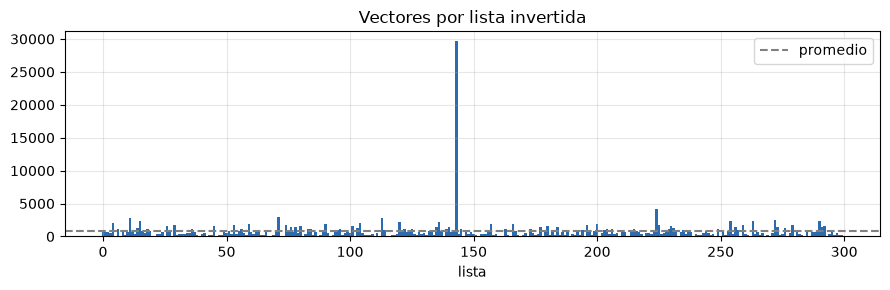

In [10]:
n_l = listas.count()
coinciden = (km.transform(vectores).select("ocid", "lista").join(listas.select("ocid", F.col("lista").alias("lista_udf")), "ocid")
               .where("lista = lista_udf").count())
print(f"Listas asignadas: {n_l:,} de {N:,} | coinciden con predict de KMeans: {coinciden:,} ({coinciden / N:.1%})")
assert n_l == N and listas.where(F.size("listas_probe") != NPROBE).count() == 0

tam = listas.groupBy("lista").count().orderBy("lista").toPandas()
print(f"Tamaño de lista: min {tam['count'].min():,} | mediana {tam['count'].median():,.0f} | max {tam['count'].max():,} | listas vacías: {NLIST - len(tam)}")
listas.groupBy("categoria").agg(F.countDistinct("lista").alias("listas_usadas"), F.count("*").alias("vectores")).show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(tam["lista"], tam["count"], width=1, color="#2b6cb0"); ax.axhline(N / NLIST, color="gray", ls="--", label="promedio")
ax.set_title("Vectores por lista invertida"); ax.set_xlabel("lista"); ax.legend(); mostrar_fig("tamano_listas")

- KMeans con k=300 en 32 s; el 100% de las asignaciones coincide con `predict`

- Listas muy desiguales: mediana de 502 vectores y máximo de 29,676, porque las descripciones genéricas ("servicio de…", "adquisición de…") forman listas enormes

- Por eso el costo de una consulta depende de dónde cae: una consulta en la lista grande revisa ~60 veces más vectores que una en una lista mediana

### 4. Escritura de resultados

- Centroides y listas ya están en `temp/b_ind_ivf/centroides` y `listas` (insumo de `c_bus_ivf`)

- Tablas en `temp/b_ind_ivf/tablas` (parquet) y `web/` (json)

In [11]:
resumen = pd.DataFrame([{"vectores": N, "nlist": NLIST, "nprobe": NPROBE, "seg_kmeans": round(seg_km, 1),
                         "lista_min": int(tam["count"].min()), "lista_mediana": float(tam["count"].median()), "lista_max": int(tam["count"].max())}])
tablas = {"tamano_listas": tam, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/b_ind_ivf/: {', '.join(escritos)}")

Escrito en temp/b_ind_ivf/: tamano_listas, resumen


#### a. Verificación

In [12]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 2 tablas (parquet + json) | 1 figuras: tamano_listas


---
### 5. Cerrar sesión

In [13]:
spark.stop()